In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

zip_path = '/content/drive/MyDrive/Capstone/road_surface.zip'
extract_to = '/content/road_surface'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)


In [ ]:
DATA_DIR = '/content/road_surface/road_surface'

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")

dry_asphalt_smooth: 8233 images
fresh_snow: 9991 images
ice: 10000 images
wet_asphalt_smooth: 9981 images


In [ ]:
#Renaming files to classification of dry, snow, wet and ice
renames = {
    'dry_asphalt_smooth': 'dry',
    'fresh_snow': 'snow',
    'wet_asphalt_smooth': 'wet',
    'ice': 'ice'
}

for old, new in renames.items():
    old_path = os.path.join(DATA_DIR, old)
    new_path = os.path.join(DATA_DIR, new)
    if os.path.exists(old_path) and old != new:
        os.rename(old_path, new_path)

print(sorted(os.listdir(DATA_DIR)))


['dry', 'ice', 'snow', 'wet']


In [ ]:
# checking the integrity of the images
from PIL import Image

exts = ('.jpg', '.jpeg', '.png', '.bmp')

corrupt = []
total = 0

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        if not fname.lower().endswith(exts):
            continue
        fpath = os.path.join(class_path, fname)
        total += 1
        try:
            with Image.open(fpath) as img:
                img.verify()   # checks file integrity without fully loading
        except Exception as e:
            corrupt.append(fpath)
            print(f"CORRUPT: {fpath}  ({e})")

print(f"\nScanned {total} images")
print(f"Found {len(corrupt)} corrupt files")


Scanned 38205 images
Found 0 corrupt files


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

Device: cuda
GPU: Tesla T4


In [ ]:
# Training augmentation
train_transform = transforms.Compose([
  transforms.Resize((256, 256)),
  transforms.RandomResizedCrop(224, scale=(0.4, 1.0)),
  transforms.RandomHorizontalFlip(),
  transforms.ColorJitter(brightness=0.3, contrast=0.3),
  transforms.RandomRotation(10),
  transforms.ToTensor(),
  transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Validation
val_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Load the full dataset
full_dataset = datasets.ImageFolder(DATA_DIR)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

# 80/20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

Classes: ['dry', 'ice', 'snow', 'wet']
Total images: 38205


In [ ]:
# Split indices, then apply different transforms to each
train_subset, val_subset = random_split(
  full_dataset, [train_size, val_size],
  generator=torch.Generator().manual_seed(42)
)

In [ ]:
# Apply the correct transform to each split
train_subset.dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_subset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

In [ ]:
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
print(f"Train: {len(train_subset)}, Val: {len(val_subset)}")

Train: 30564, Val: 7641


In [ ]:
#Training model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]


In [ ]:
# Freeze the backbone
for param in model.parameters():
  param.requires_grad = False

In [ ]:
# Replace classifier head for 4 classes
num_classes = 4
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

In [ ]:
# Moving the model to the GPU
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

In [ ]:
# Training block
def train_epoch():
  model.train()
  running_loss = 0
  for imgs, labels in train_loader:
    imgs, labels = imgs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  return running_loss / len(train_loader)

In [ ]:
def validate():
  model.eval()
  correct = total = 0
  with torch.no_grad():
    for imgs, labels in val_loader:
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs)
      _, pred = torch.max(outputs, 1)
      correct += (pred == labels).sum().item()
      total += labels.size(0)
  return correct / total

In [ ]:
EPOCHS = 10
for epoch in range(EPOCHS):
  loss = train_epoch()
  acc = validate()
  print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}  val_acc={acc:.4f}")

Epoch 1/10  loss=0.4842  val_acc=0.8388
Epoch 2/10  loss=0.4852  val_acc=0.8380
Epoch 3/10  loss=0.4975  val_acc=0.8414
Epoch 4/10  loss=0.4814  val_acc=0.8394
Epoch 5/10  loss=0.5048  val_acc=0.8185
Epoch 6/10  loss=0.4956  val_acc=0.8356
Epoch 7/10  loss=0.4929  val_acc=0.8389
Epoch 8/10  loss=0.4926  val_acc=0.8449
Epoch 9/10  loss=0.4914  val_acc=0.8464
Epoch 10/10  loss=0.4900  val_acc=0.8402


In [ ]:
def get_all_predictions(loader):
    model.eval()
    y_true, y_pred = [], []          # ← these persist and collect everything

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            # KEY DIFFERENCE — store instead of just counting
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

              precision    recall  f1-score   support

         dry       0.73      0.70      0.72      1634
         ice       0.89      0.92      0.90      1947
        snow       0.95      0.90      0.93      2082
         wet       0.77      0.81      0.79      1978

    accuracy                           0.84      7641
   macro avg       0.84      0.83      0.83      7641
weighted avg       0.84      0.84      0.84      7641



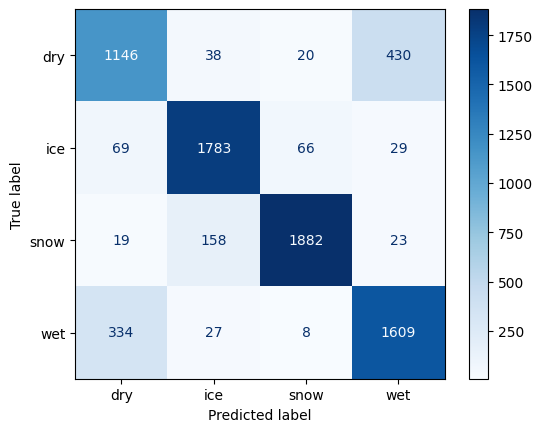

In [ ]:
y_true, y_pred = get_all_predictions(val_loader)

#The metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_true, y_pred, target_names=['dry','ice','snow','wet']))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['dry','ice','snow','wet']).plot(cmap='Blues')
plt.show()